In [4]:
import pandas as pd
from pathlib import Path

# Run with cwd = thesis repo root, or from 04_SentimentAnalysis (then we go up one level).
root = Path.cwd()
if root.name == "04_SentimentAnalysis":
    root = root.parent

df_topic_assignments = pd.read_csv(root / "02_TopicModeling/outputs/03_new_topic_assignments.csv")
df = pd.read_csv(root / "04_SentimentAnalysis/outputs/emotion_fulltext_results.csv")

_manual = ["Manual Topic Label", "Manual Cluster Label"]
df = df.merge(
    df_topic_assignments[["row_id", *_manual]].drop_duplicates("row_id"),
    on="row_id",
    how="left",
)


In [ ]:
df_topic_assignments

,Date,Title,Text,source,row_id,topic_label_current,Manual Topic Label,Manual Cluster Label
0,2025-08-01,Bereitet der Westen die Entmachtung oder sogar...,Der Streit um das Nationale Anti-Korruptionsbü...,Antispiegel,1,Topic 10 — weidel_gießen_chrupalla_jugendorgan...,AfD Party Politics,German Party Politics
1,2025-08-01,EU-Kommission hat Textnachrichten zum Kauf der...,Die New York Times versucht seit langem vor Ge...,Antispiegel,2,Topic 22 — google_digitale_digitalen_nutzer,Big Tech and AI,German Economy & Industry
2,2025-08-01,Wahlkommission rechtfertigt Einmischung der EU...,Ende September stehen in Moldawien Parlamentsw...,Antispiegel,3,Topic 26 — moldawien_sandu_wahlen_orbán,Eastern European Politics,International Affairs
3,2025-08-02,Fordert Russland wirklich die Vernichtung alle...,Ich bin auf die Geschichte zuerst bei RT-DE ge...,Antispiegel,4,Topic 7 — ukrainischen_ukrainische_kiew_streit...,Ukrainian Military Operations,Russia-Ukraine War
4,2025-08-02,Der Spiegel macht mal wieder Berichterstattung...,"Wer auch nicht-westliche Medien liest, der ist...",Antispiegel,5,Topic 53 — selensky_nabu_leser_bellingcat,Corruption Journalism,Media & Information Ecosystem
...,...,...,...,...,...,...,...,...
20435,2026-01-03,Bis zu 100 Sternschnuppen pro Stunde sind möglich,Rechtzeitig zum neuen Jahr zeigt sich der Ster...,Tagesschau,20436,Topic 54 — schnee_dwd_winter_grad,Winter Weather,"Energy, Climate & Environment"
20436,2025-12-04,"Der letzte ""Supermond"" des Jahres","In der kommenden Nacht wird ein ""Supermond"" am...",Tagesschau,20437,Topic 63 — gold_silber_unze_us dollar,Precious Metals Markets,Finance & Markets
20437,2025-11-06,Gute Sicht auf den größten Vollmond des Jahres,Der Mond war in der Nacht zu Donnerstag besond...,Tagesschau,20438,Topic 54 — schnee_dwd_winter_grad,Winter Weather,"Energy, Climate & Environment"
20438,2025-11-19,Projekt zur Tierbeobachtung startet wieder,ICARUS begann 2020 mit einer Antenne auf dem r...,Tagesschau,20439,Topic 12 — drohnen_nato_polen_luftraum,NATO Air/Missile Defense,Russia-Ukraine War


In [11]:
df['Manual Cluster Label'].value_counts()

Manual Cluster Label
German Party Politics                        2267
Miscellaneous                                1748
US & Transatlantic Politics                  1747
Russia-Ukraine War                           1305
Middle East                                  1303
German Economy & Industry                    1293
Russia (-Ukraine) Diplomacy & Sanctions      1262
Social Policy & Welfare                      1260
International Affairs                         995
Energy, Climate & Environment                 950
Justice System & Political Conflict           934
Russia-Ukraine Diplomacy & Sanctions          776
Migration & Internal Security                 775
Free Speech, Crime & Political Repression     762
Media & Information Ecosystem                 639
Finance & Markets                             551
German Military & Defense                     437
Identity & Culture War                        426
Health & COVID-19                             378
Name: count, dtype: int64

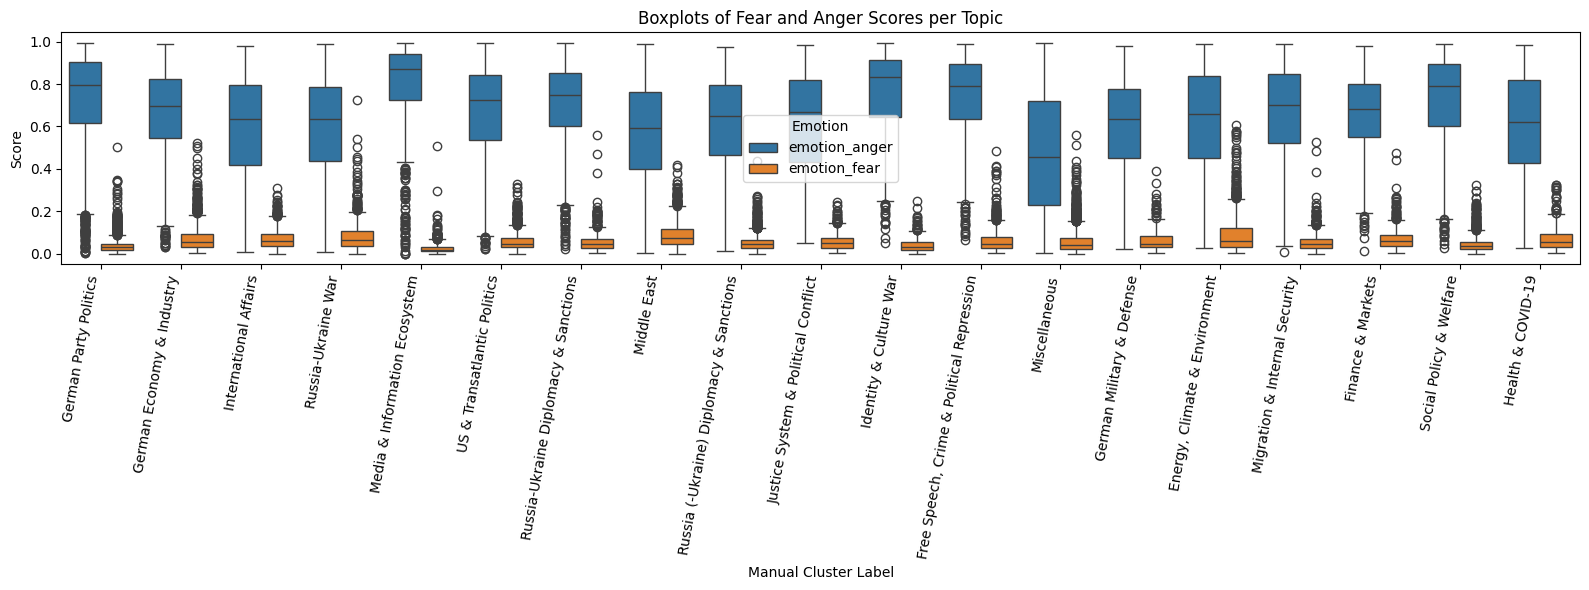

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check for relevant columns
emotion_columns = [col for col in df.columns if col.lower() in ['fear', 'anger']]
if not emotion_columns:
    # Try common HuggingFace emotion keys if not standard
    emotion_columns = [col for col in df.columns if "fear" in col.lower() or "anger" in col.lower()]
if len(emotion_columns) < 2:
    raise ValueError("Could not find both 'fear' and 'anger' columns in emotion results.")

# For the rest, we expect:
# - df['Manual Topic Label'] labels topics
# - df['fear'] or similar is the fear score
# - df['anger'] or similar is the anger score

# Only keep topics with sufficient samples (optional: drop tiny topics for clarity)
topic_counts = df['Manual Cluster Label'].value_counts()
major_topics = topic_counts[topic_counts > 20].index  # filter for topics with >20 samples
df_plot = df[df['Manual Cluster Label'].isin(major_topics)]

# Melt dataframe to plot both emotions per topic
df_melted = df_plot.melt(
    id_vars=["Manual Cluster Label"],
    value_vars=emotion_columns,
    var_name="Emotion",
    value_name="Score"
)

plt.figure(figsize=(16, 6))
sns.boxplot(
    data=df_melted,
    x="Manual Cluster Label",
    y="Score",
    hue="Emotion"
)
plt.xticks(rotation=80, ha="right")
plt.title('Boxplots of Fear and Anger Scores per Topic')
plt.tight_layout()
plt.show()

## Emotion per topic (heatmap)

### anger

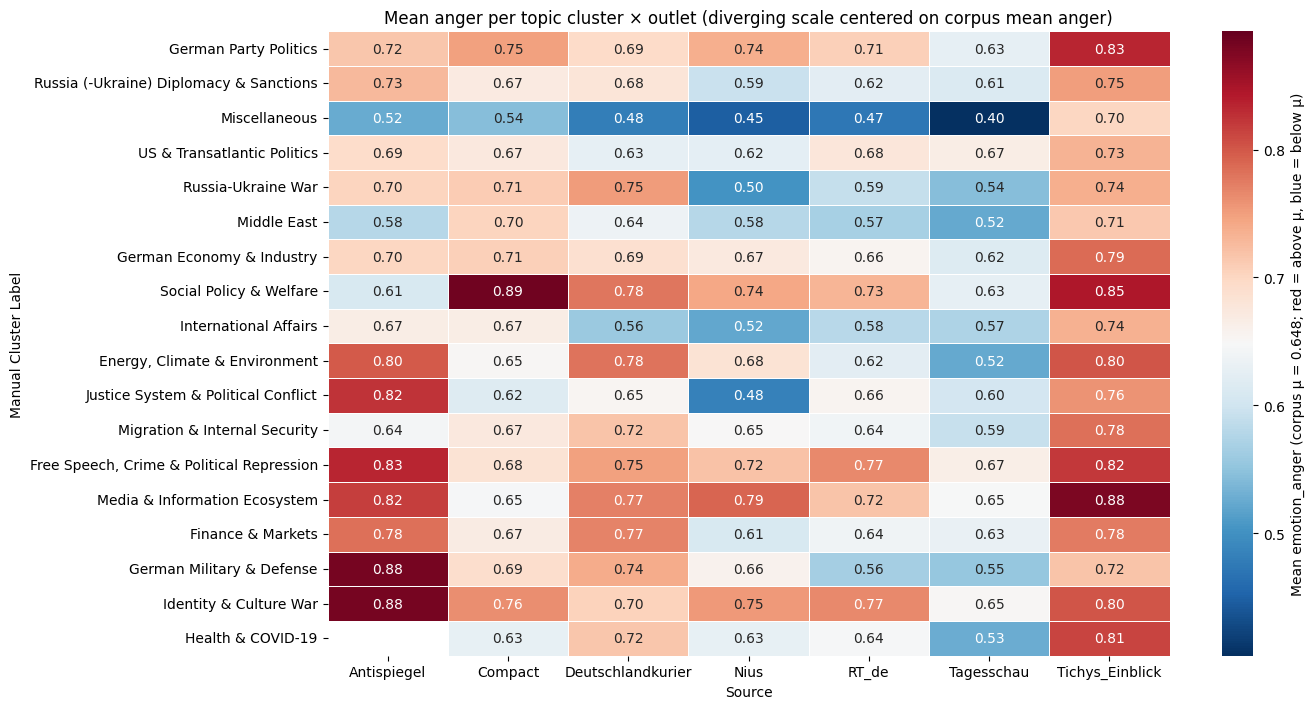

In [37]:
# Per-topic-cluster × outlet mean anger; colors vs corpus-wide mean anger

import numpy as np

if "Manual Cluster Label" not in df.columns or "source" not in df.columns:
    raise ValueError("df must contain 'Manual Cluster Label' and 'source'.")
if not any("anger" in c.lower() for c in df.columns):
    raise ValueError("df must contain an anger score column.")

anger_col = next(c for c in df.columns if "anger" in c.lower())

# Reference: mean anger over the full corpus (same column)
overall_anger_mean = float(df[anger_col].mean())

major_topics = df["Manual Cluster Label"].value_counts()
major_topics = major_topics[major_topics > 20].index
df_major = df[df["Manual Cluster Label"].isin(major_topics)].copy()

pivot = (
    df_major.groupby(["Manual Cluster Label", "source"])[anger_col]
    .mean()
    .unstack("source")
)

vals = pivot.to_numpy(dtype=float)
lo, hi = float(np.nanmin(vals)), float(np.nanmax(vals))
spread = max(hi - overall_anger_mean, overall_anger_mean - lo)
if spread == 0:
    spread = 1e-6
vmin = overall_anger_mean - spread
vmax = overall_anger_mean + spread

pivot = pivot.reindex(index=[x for x in major_topics if x in pivot.index])

plt.figure(figsize=(14, max(6, 0.4 * len(pivot))))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=overall_anger_mean,
    vmin=vmin,
    vmax=vmax,
    linewidths=0.5,
    cbar_kws={
        "label": f"Mean {anger_col} (corpus μ = {overall_anger_mean:.3f}; red = above μ, blue = below μ)",
    },
)
plt.ylabel("Manual Cluster Label")
plt.xlabel("Source")
plt.title("Mean anger per topic cluster × outlet (diverging scale centered on corpus mean anger)")
plt.tight_layout()
plt.show()



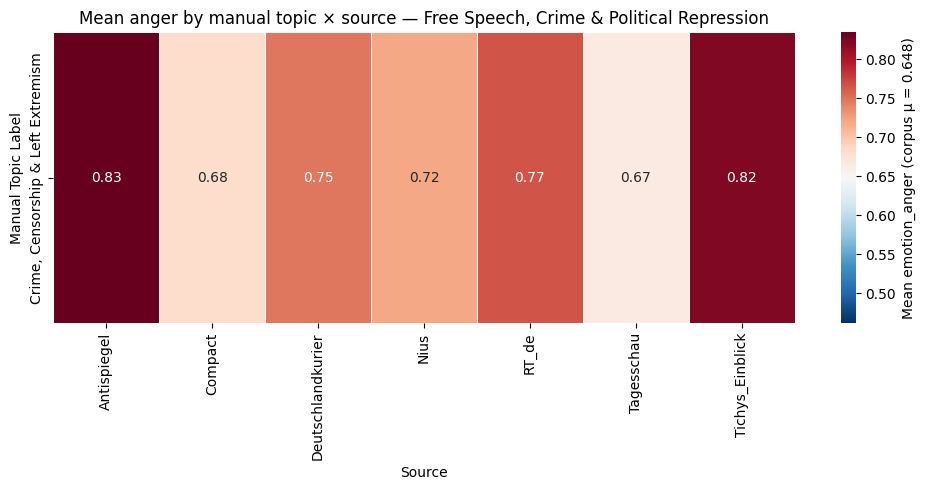

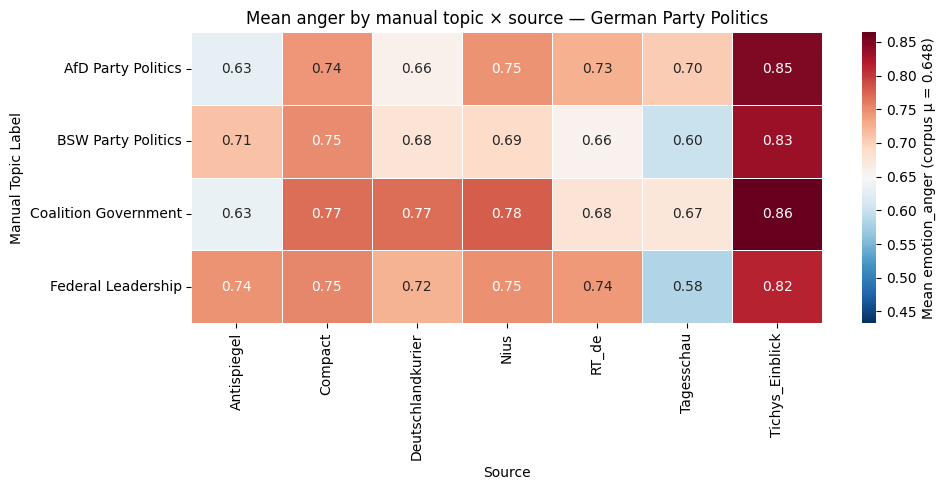

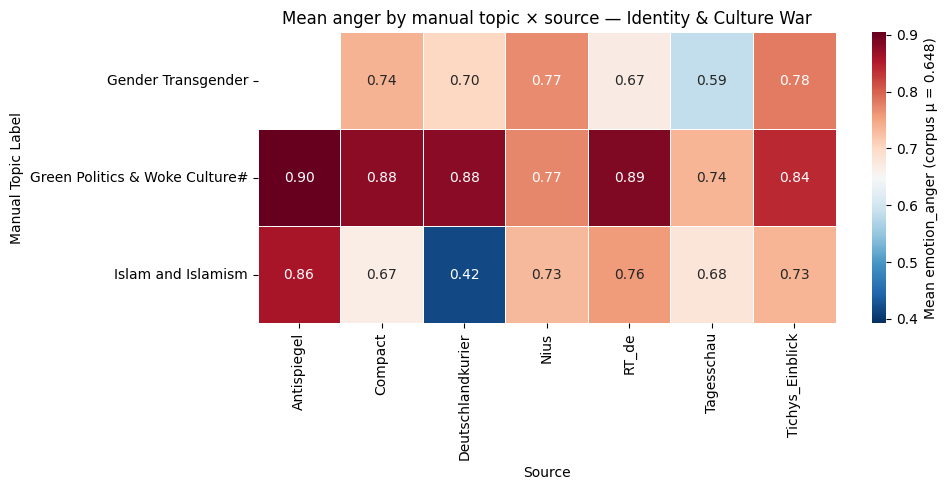

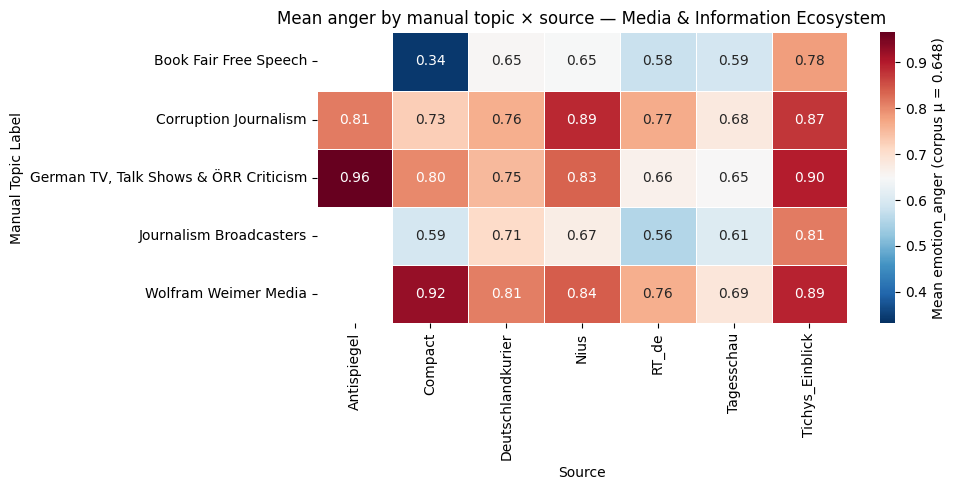

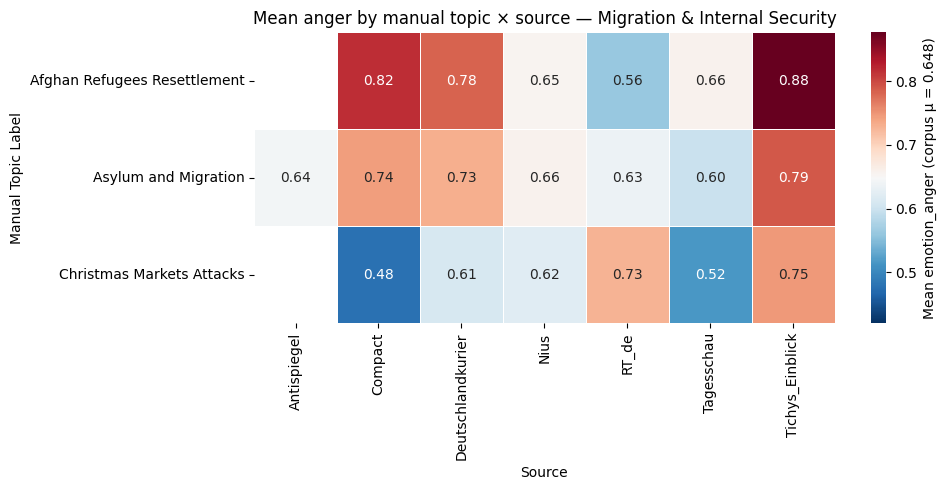

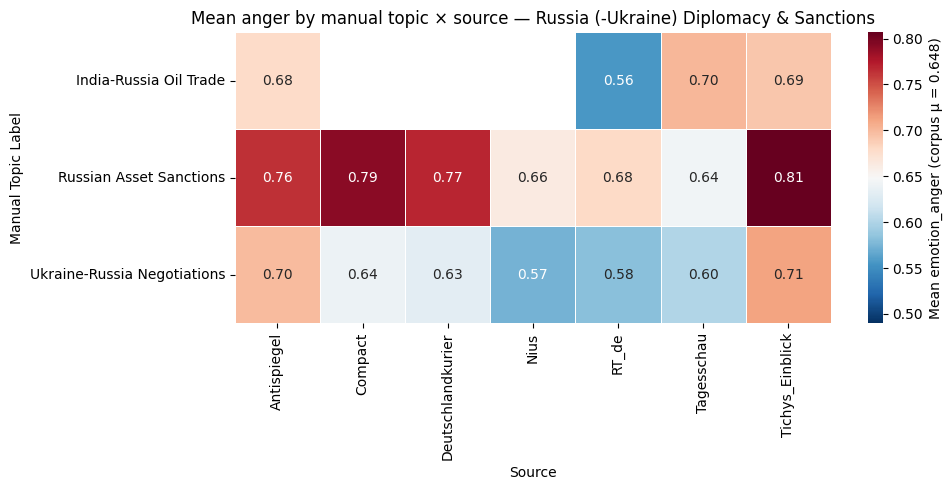

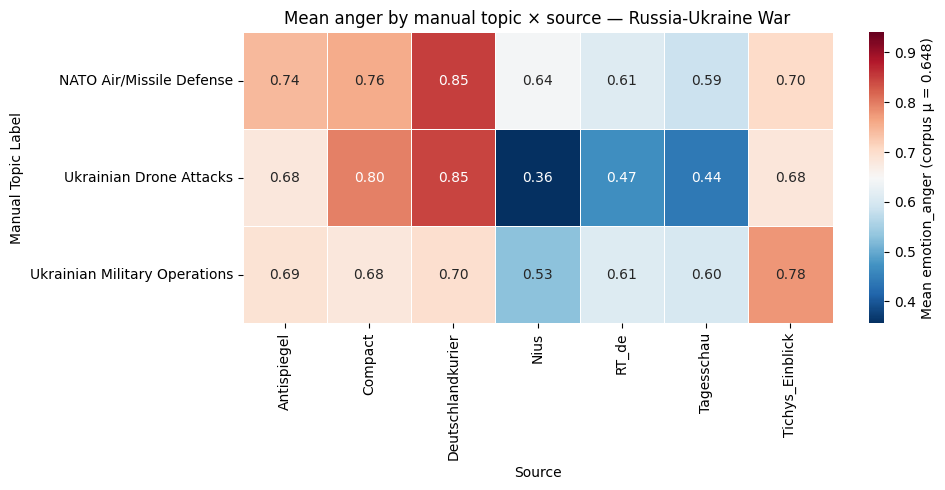

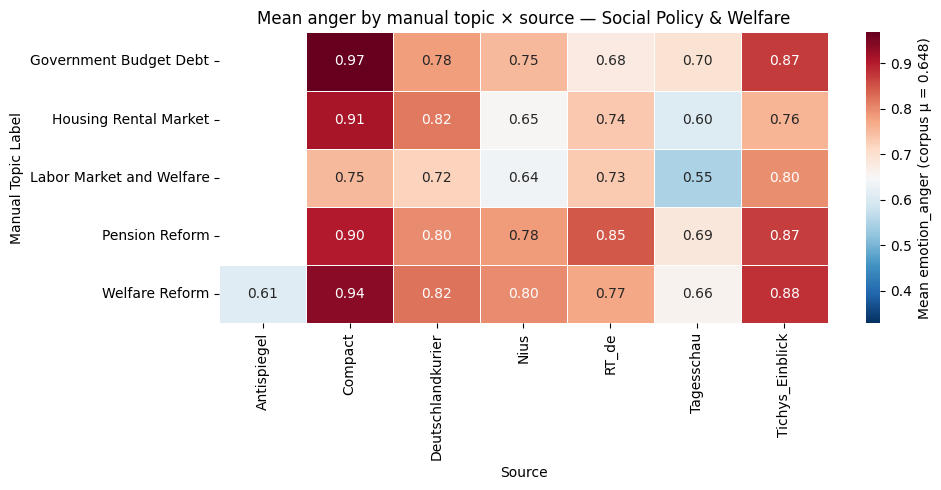

In [36]:
# One heatmap per selected manual cluster: mean anger by Manual Topic Label × source

import numpy as np

CLUSTER_LABELS = [
    "Free Speech, Crime & Political Repression",
    "German Party Politics Total",
    "Identity & Culture War Total",
    "Media & Information Ecosystem Total",
    "Migration & Internal Security",
    "Russia (-Ukraine) Diplomacy & Sanctions",
    "Russia-Ukraine War",
    "Social Policy & Welfare",
]

_ALIASES = {
    "German Party Politics Total": "German Party Politics",
    "Identity & Culture War Total": "Identity & Culture War",
    "Media & Information Ecosystem Total": "Media & Information Ecosystem",
}


def _resolve_manual_cluster(name: str, available: set[str]) -> str | None:
    if name in available:
        return name
    if name in _ALIASES and _ALIASES[name] in available:
        return _ALIASES[name]
    stripped = name[:-6].strip() if name.endswith(" Total") else name.strip()
    if stripped in available:
        return stripped
    return None


if "Manual Topic Label" not in df.columns:
    raise ValueError("df must contain 'Manual Topic Label' (merge topic assignments first).")
if not any("anger" in c.lower() for c in df.columns):
    raise ValueError("No anger column found.")

anger_col = next(c for c in df.columns if "anger" in c.lower())
overall_anger_mean = float(df[anger_col].mean())

available = set(df["Manual Cluster Label"].dropna().astype(str).unique())

for raw in CLUSTER_LABELS:
    resolved = _resolve_manual_cluster(raw, available)
    if resolved is None:
        print(f"Skip (unknown label): {raw!r}")
        continue

    sub = df.loc[df["Manual Cluster Label"] == resolved].copy()
    if sub.empty:
        print(f"Skip (no rows): {resolved!r}")
        continue

    # Topic-level: rows = manual topic, columns = outlet
    pivot = (
        sub.groupby(["Manual Topic Label", "source"])[anger_col]
        .mean()
        .unstack("source")
    )

    # Optional: drop manual topics with very few articles in this cluster
    min_n = 5
    topic_n = sub.groupby("Manual Topic Label", dropna=False).size()
    keep = topic_n[topic_n >= min_n].index
    pivot = pivot.reindex(index=pivot.index.intersection(keep)).sort_index()

    if pivot.empty:
        print(f"Skip (no topics with n≥{min_n}): {resolved!r}")
        continue

    vals = pivot.to_numpy(dtype=float)
    lo, hi = float(np.nanmin(vals)), float(np.nanmax(vals))
    spread = max(hi - overall_anger_mean, overall_anger_mean - lo)
    if spread == 0:
        spread = 1e-6
    vmin, vmax = overall_anger_mean - spread, overall_anger_mean + spread

    n_r, n_c = pivot.shape
    plt.figure(figsize=(max(10, 0.55 * n_c), max(5, 0.38 * n_r)))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=overall_anger_mean,
        vmin=vmin,
        vmax=vmax,
        linewidths=0.5,
        cbar_kws={"label": f"Mean {anger_col} (corpus μ = {overall_anger_mean:.3f})"},
    )
    plt.title(f"Mean anger by manual topic × source — {resolved}")
    plt.xlabel("Source")
    plt.ylabel("Manual Topic Label")
    plt.tight_layout()
    plt.show()



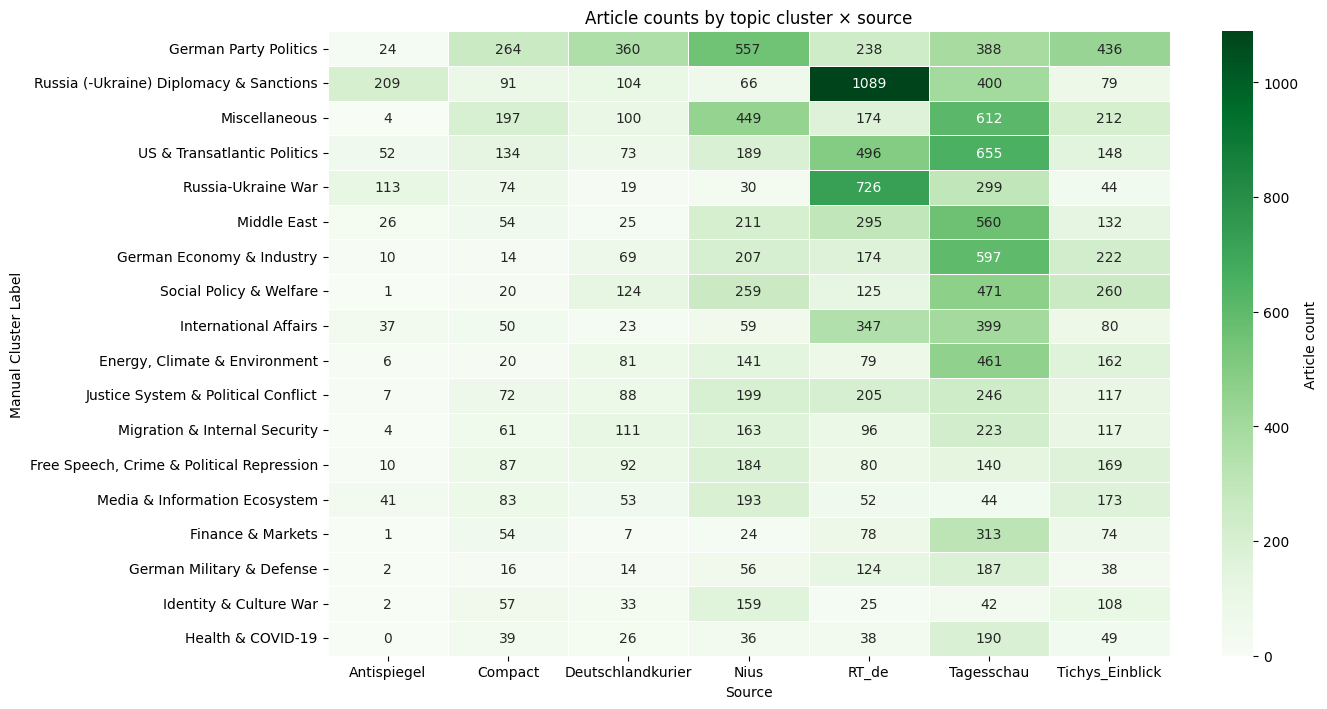

In [40]:
# Depict counts per outlet per topic cluster

# Count articles per (cluster, outlet)
counts = (
    df.groupby(["Manual Cluster Label", "source"])
    .size()
    .unstack("source", fill_value=0)
)

# Optionally: restrict to major topics as in the 'fear' analysis
major_topics = df["Manual Cluster Label"].value_counts()
major_topics = major_topics[major_topics > 20].index
counts = counts.loc[[x for x in major_topics if x in counts.index]]

plt.figure(figsize=(14, max(6, 0.4 * len(counts))))
sns.heatmap(
    counts,
    annot=True,
    fmt="d",
    cmap="Greens",
    linewidths=0.5,
    cbar_kws={"label": "Article count"},
)
plt.title("Article counts by topic cluster × source")
plt.xlabel("Source")
plt.ylabel("Manual Cluster Label")
plt.tight_layout()
plt.show()

## fear

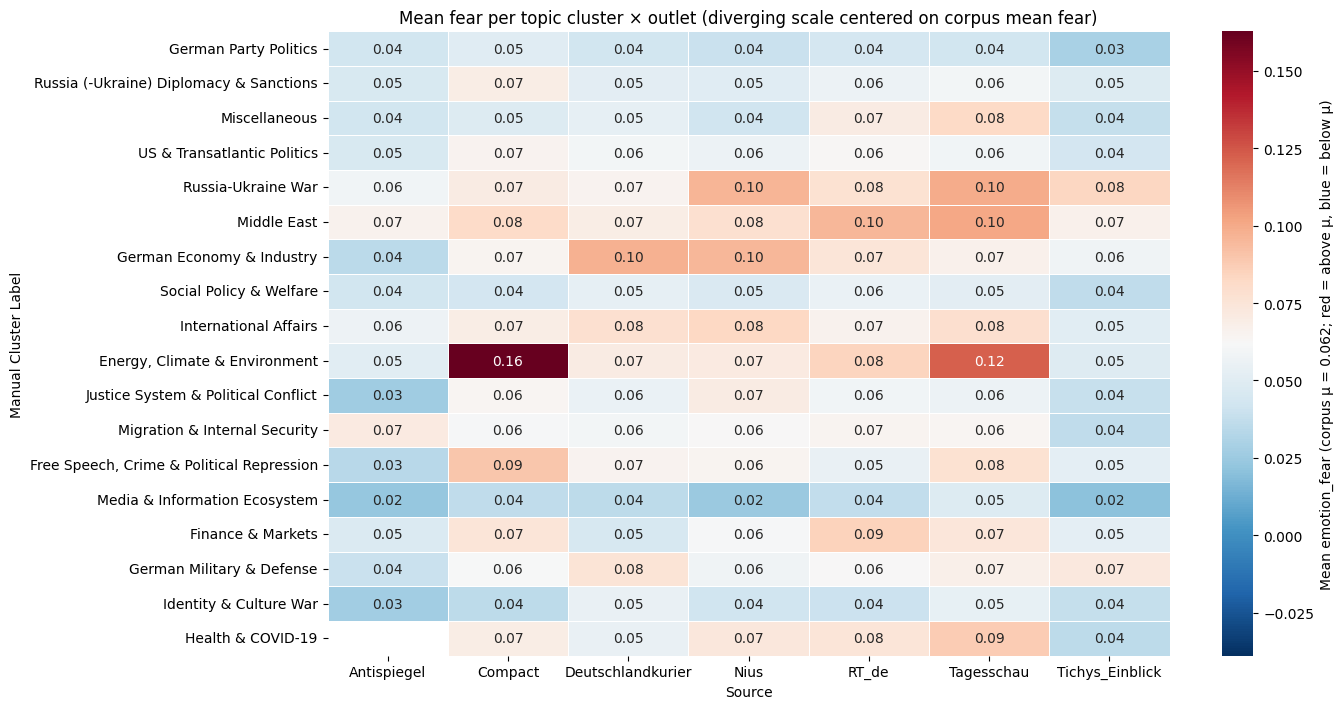

In [39]:
# Per-topic-cluster × outlet mean anger; colors vs corpus-wide mean anger

if "Manual Cluster Label" not in df.columns or "source" not in df.columns:
    raise ValueError("df must contain 'Manual Cluster Label' and 'source'.")
if not any("fear" in c.lower() for c in df.columns):
    raise ValueError("df must contain an anger score column.")

fear_col = next(c for c in df.columns if "fear" in c.lower())

# Reference: mean fear over the full corpus (same column)
overall_fear_mean = float(df[fear_col].mean())

major_topics = df["Manual Cluster Label"].value_counts()
major_topics = major_topics[major_topics > 20].index
df_major = df[df["Manual Cluster Label"].isin(major_topics)].copy()

pivot = (
    df_major.groupby(["Manual Cluster Label", "source"])[fear_col]
    .mean()
    .unstack("source")
)

vals = pivot.to_numpy(dtype=float)
lo, hi = float(np.nanmin(vals)), float(np.nanmax(vals))
spread = max(hi - overall_fear_mean, overall_fear_mean - lo)
if spread == 0:
    spread = 1e-6
vmin = overall_fear_mean - spread
vmax = overall_fear_mean + spread

pivot = pivot.reindex(index=[x for x in major_topics if x in pivot.index])

plt.figure(figsize=(14, max(6, 0.4 * len(pivot))))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=overall_fear_mean,
    vmin=vmin,
    vmax=vmax,
    linewidths=0.5,
    cbar_kws={
        "label": f"Mean {fear_col} (corpus μ = {overall_fear_mean:.3f}; red = above μ, blue = below μ)",
    },
)
plt.ylabel("Manual Cluster Label")
plt.xlabel("Source")
plt.title("Mean fear per topic cluster × outlet (diverging scale centered on corpus mean fear)")
plt.tight_layout()
plt.show()



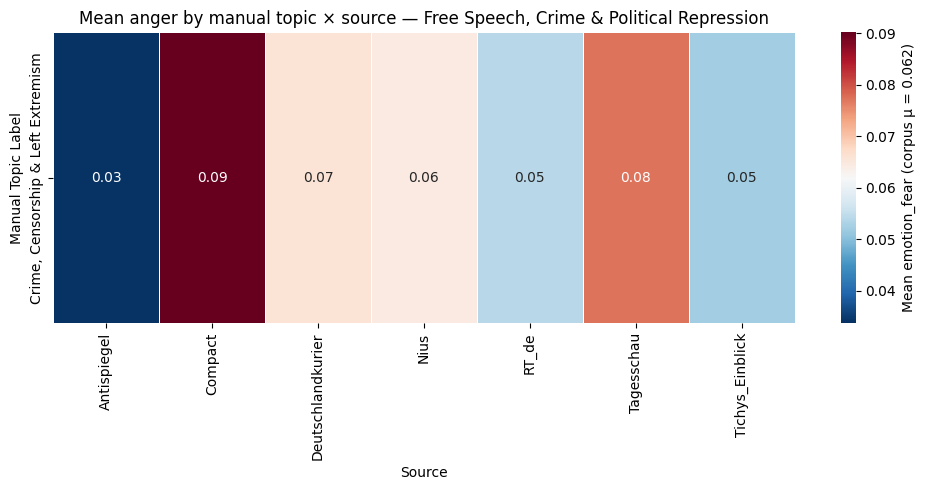

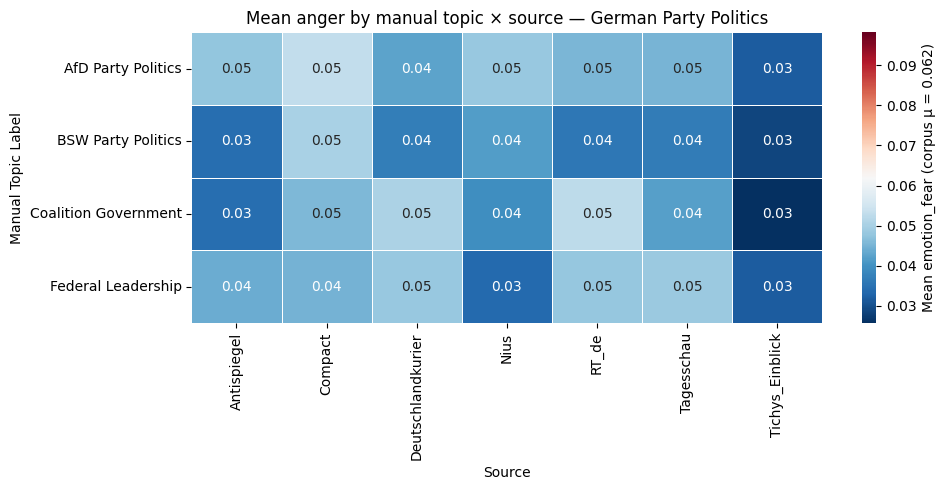

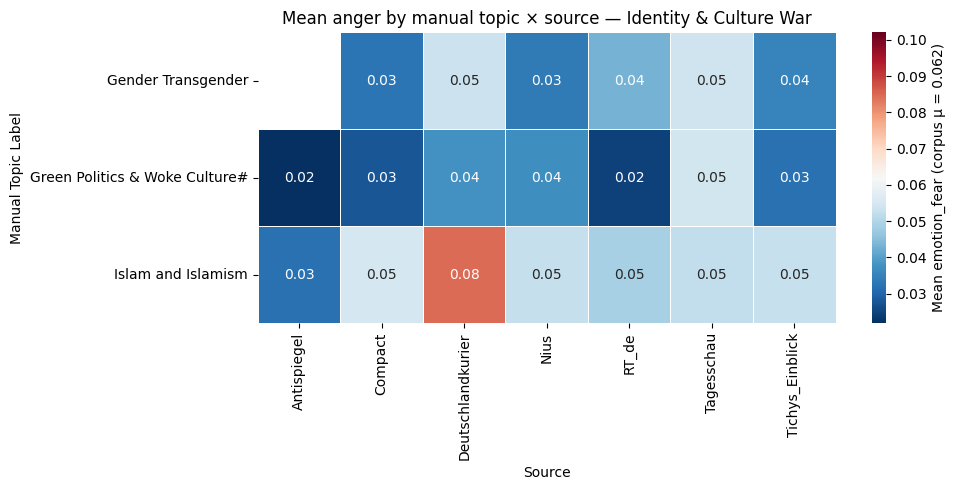

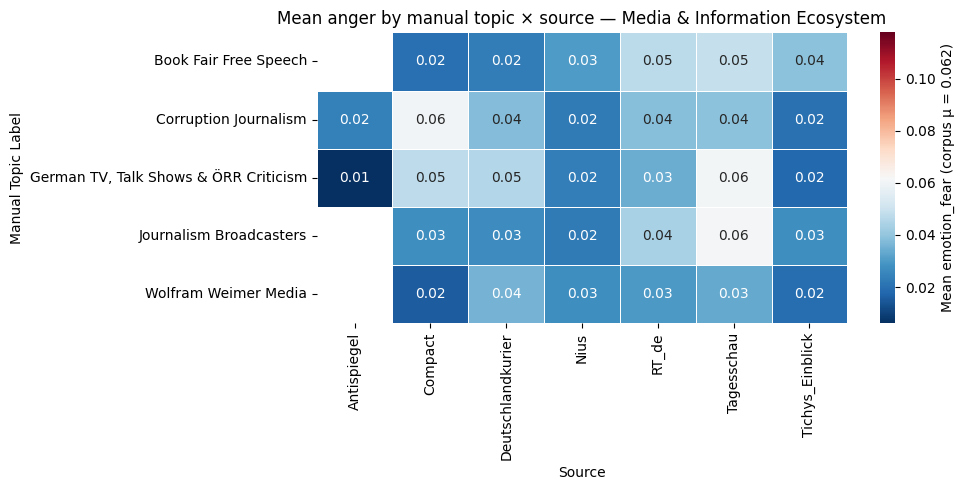

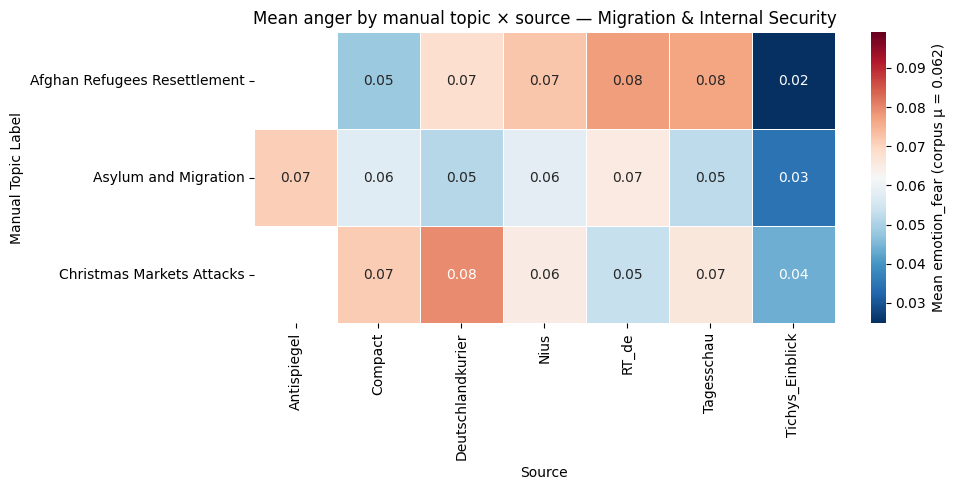

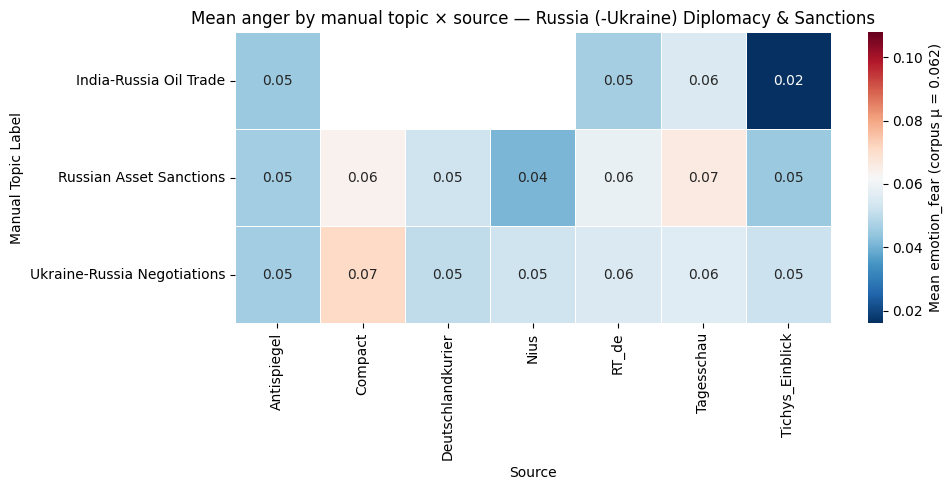

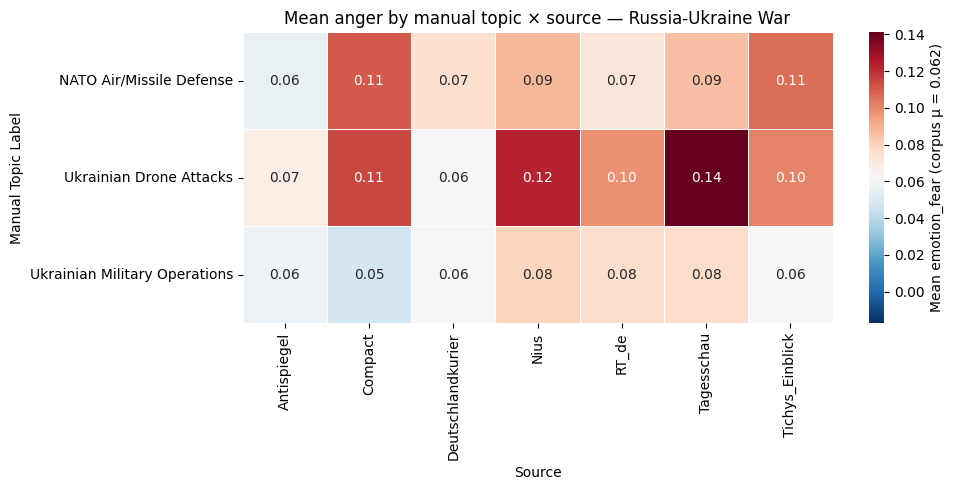

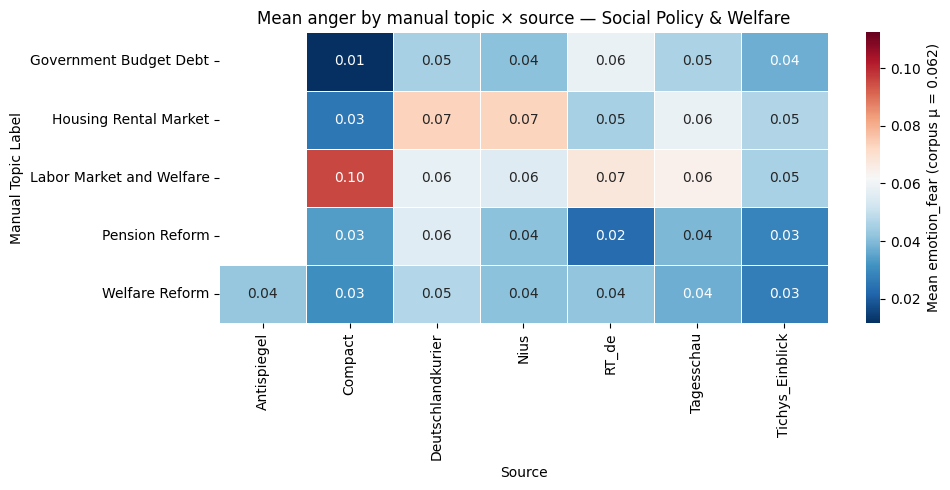

In [42]:
# One heatmap per selected manual cluster: mean anger by Manual Topic Label × source

CLUSTER_LABELS = [
    "Free Speech, Crime & Political Repression",
    "German Party Politics Total",
    "Identity & Culture War Total",
    "Media & Information Ecosystem Total",
    "Migration & Internal Security",
    "Russia (-Ukraine) Diplomacy & Sanctions",
    "Russia-Ukraine War",
    "Social Policy & Welfare",
]

_ALIASES = {
    "German Party Politics Total": "German Party Politics",
    "Identity & Culture War Total": "Identity & Culture War",
    "Media & Information Ecosystem Total": "Media & Information Ecosystem",
}


def _resolve_manual_cluster(name: str, available: set[str]) -> str | None:
    if name in available:
        return name
    if name in _ALIASES and _ALIASES[name] in available:
        return _ALIASES[name]
    stripped = name[:-6].strip() if name.endswith(" Total") else name.strip()
    if stripped in available:
        return stripped
    return None


if "Manual Topic Label" not in df.columns:
    raise ValueError("df must contain 'Manual Topic Label' (merge topic assignments first).")
if not any("fear" in c.lower() for c in df.columns):
    raise ValueError("No anfearger column found.")

fear_col = next(c for c in df.columns if "fear" in c.lower())
overall_fear_mean = float(df[fear_col].mean())

available = set(df["Manual Cluster Label"].dropna().astype(str).unique())

for raw in CLUSTER_LABELS:
    resolved = _resolve_manual_cluster(raw, available)
    if resolved is None:
        print(f"Skip (unknown label): {raw!r}")
        continue

    sub = df.loc[df["Manual Cluster Label"] == resolved].copy()
    if sub.empty:
        print(f"Skip (no rows): {resolved!r}")
        continue

    # Topic-level: rows = manual topic, columns = outlet
    pivot = (
        sub.groupby(["Manual Topic Label", "source"])[fear_col]
        .mean()
        .unstack("source")
    )

    # Optional: drop manual topics with very few articles in this cluster
    min_n = 5
    topic_n = sub.groupby("Manual Topic Label", dropna=False).size()
    keep = topic_n[topic_n >= min_n].index
    pivot = pivot.reindex(index=pivot.index.intersection(keep)).sort_index()

    if pivot.empty:
        print(f"Skip (no topics with n≥{min_n}): {resolved!r}")
        continue

    vals = pivot.to_numpy(dtype=float)
    lo, hi = float(np.nanmin(vals)), float(np.nanmax(vals))
    spread = max(hi - overall_fear_mean, overall_fear_mean - lo)
    if spread == 0:
        spread = 1e-6
    vmin, vmax = overall_fear_mean - spread, overall_fear_mean + spread

    n_r, n_c = pivot.shape
    plt.figure(figsize=(max(10, 0.55 * n_c), max(5, 0.38 * n_r)))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=overall_fear_mean,
        vmin=vmin,
        vmax=vmax,
        linewidths=0.5,
        cbar_kws={"label": f"Mean {fear_col} (corpus μ = {overall_fear_mean:.3f})"},
    )
    plt.title(f"Mean anger by manual topic × source — {resolved}")
    plt.xlabel("Source")
    plt.ylabel("Manual Topic Label")
    plt.tight_layout()
    plt.show()

